In [6]:

from pathlib import Path
import json

import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display

In [7]:
DATA_ROOT = Path(r"C:\Users\Khale\OneDrive\Desktop\va\balanced_100")

IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("DATA ROOT:")
print(DATA_ROOT)

DATA ROOT:
C:\Users\Khale\OneDrive\Desktop\va\balanced_100


In [ ]:

# Cell 3: Read Images


rows = []

# قراءة كل الصور داخل الكلاسات
for class_dir in DATA_ROOT.iterdir():
    
    if class_dir.is_dir():
        
        for img_path in class_dir.iterdir():
            
            if img_path.suffix.lower() in IMAGE_EXT:
                
                try:
                    with Image.open(img_path) as img:
                        
                        width, height = img.size
                        
                        rows.append({
                            "class": class_dir.name,
                            "path": str(img_path),
                            "width": width,
                            "height": height
                        })
                        
                except:
                    print("Error:", img_path)

# تحويل البيانات لـ DataFrame
df = pd.DataFrame(rows)

# أعمدة إضافية
df["aspect"] = df["width"] / df["height"]
df["pixels"] = df["width"] * df["height"]

print("Total Images:", len(df))

display(df.head())

Total Images: 432


,class,path,width,height,aspect,pixels
0,cap,C:\Users\Khale\OneDrive\Desktop\va\balanced_10...,260,320,0.812500,83200
1,cap,C:\Users\Khale\OneDrive\Desktop\va\balanced_10...,305,320,0.953125,97600
2,cap,C:\Users\Khale\OneDrive\Desktop\va\balanced_10...,304,320,0.950000,97280
3,cap,C:\Users\Khale\OneDrive\Desktop\va\balanced_10...,249,320,0.778125,79680
4,cap,C:\Users\Khale\OneDrive\Desktop\va\balanced_10...,319,320,0.996875,102080


In [ ]:

# Cell 4: Read balance_report


report_path = DATA_ROOT / "balance_report.json"

if report_path.exists():
    
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    
    print("Keys:")
    print(report.keys())

    print("\nClasses in report:")
    
    for c in report["classes"]:
        print(c["class"])

Keys:
dict_keys(['input_root', 'output_root', 'target_per_class', 'seed', 'classes'])

Classes in report:
cap
face_mask
face_shield
gloves
goggles
gown
shoe_cover


In [ ]:

# Cell 5: Count Images


class_counts = df["class"].value_counts()

print("Number of Classes:", df["class"].nunique())

print("\nImages Per Class:")
print(class_counts)

Number of Classes: 5

Images Per Class:
class
shoe_cover    100
cap            94
gown           92
gloves         83
face_mask      63
Name: count, dtype: int64


In [ ]:

# Cell 6: Resolution Statistics


print(df[["width", "height", "pixels", "aspect"]].describe())

            width      height         pixels      aspect
count  432.000000  432.000000     432.000000  432.000000
mean   282.974537  304.321759   87405.805556    0.952568
std     88.496972   51.078718   52211.885751    0.311942
min     82.000000  126.000000   24080.000000    0.256250
25%    256.000000  300.000000   71680.000000    0.800000
50%    300.000000  320.000000   89800.000000    1.000000
75%    320.000000  320.000000   96400.000000    1.049180
max    866.000000  806.000000  697996.000000    2.107527


In [ ]:

# Cell 7: Dataset Check


total_images = len(df)
total_classes = df["class"].nunique()

if total_images < 500:
    print("Dataset has less than 500 images")

if total_classes < 3:
    print("Dataset has less than 3 classes")

Dataset has less than 500 images


In [ ]:

# Cell 8: Class Imbalance


counts = class_counts.values

max_count = counts.max()
min_count = counts.min()

ratio = max_count / min_count

print("Max/Min Ratio:", round(ratio, 2))

if ratio > 2:
    print("Dataset is imbalanced")
else:
    print("Dataset is balanced")

Max/Min Ratio: 1.59
Dataset is balanced


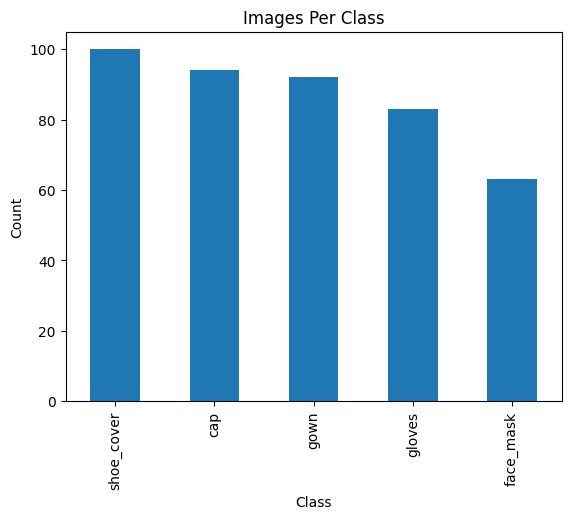

In [ ]:

# Cell 9: Simple Visualization


class_counts.plot(kind="bar")

plt.title("Images Per Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

Class Balance


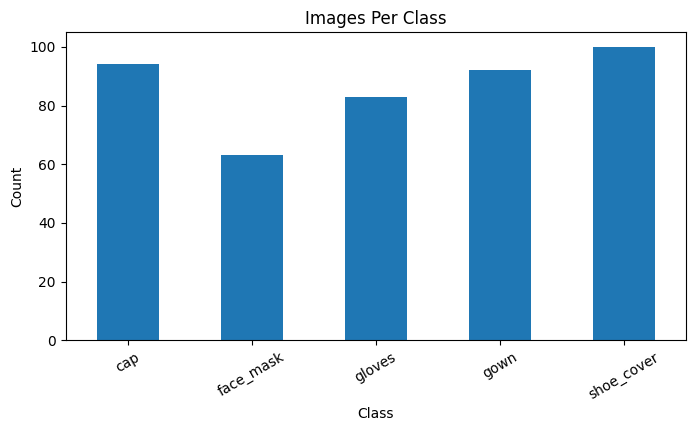

In [ ]:

# Cell 10: Class Balance Plot


print("Class Balance")

fig, ax = plt.subplots(figsize=(8, 4))

class_counts.sort_index().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Images Per Class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.xticks(rotation=30)

plt.show()

Sample Images From Each Class


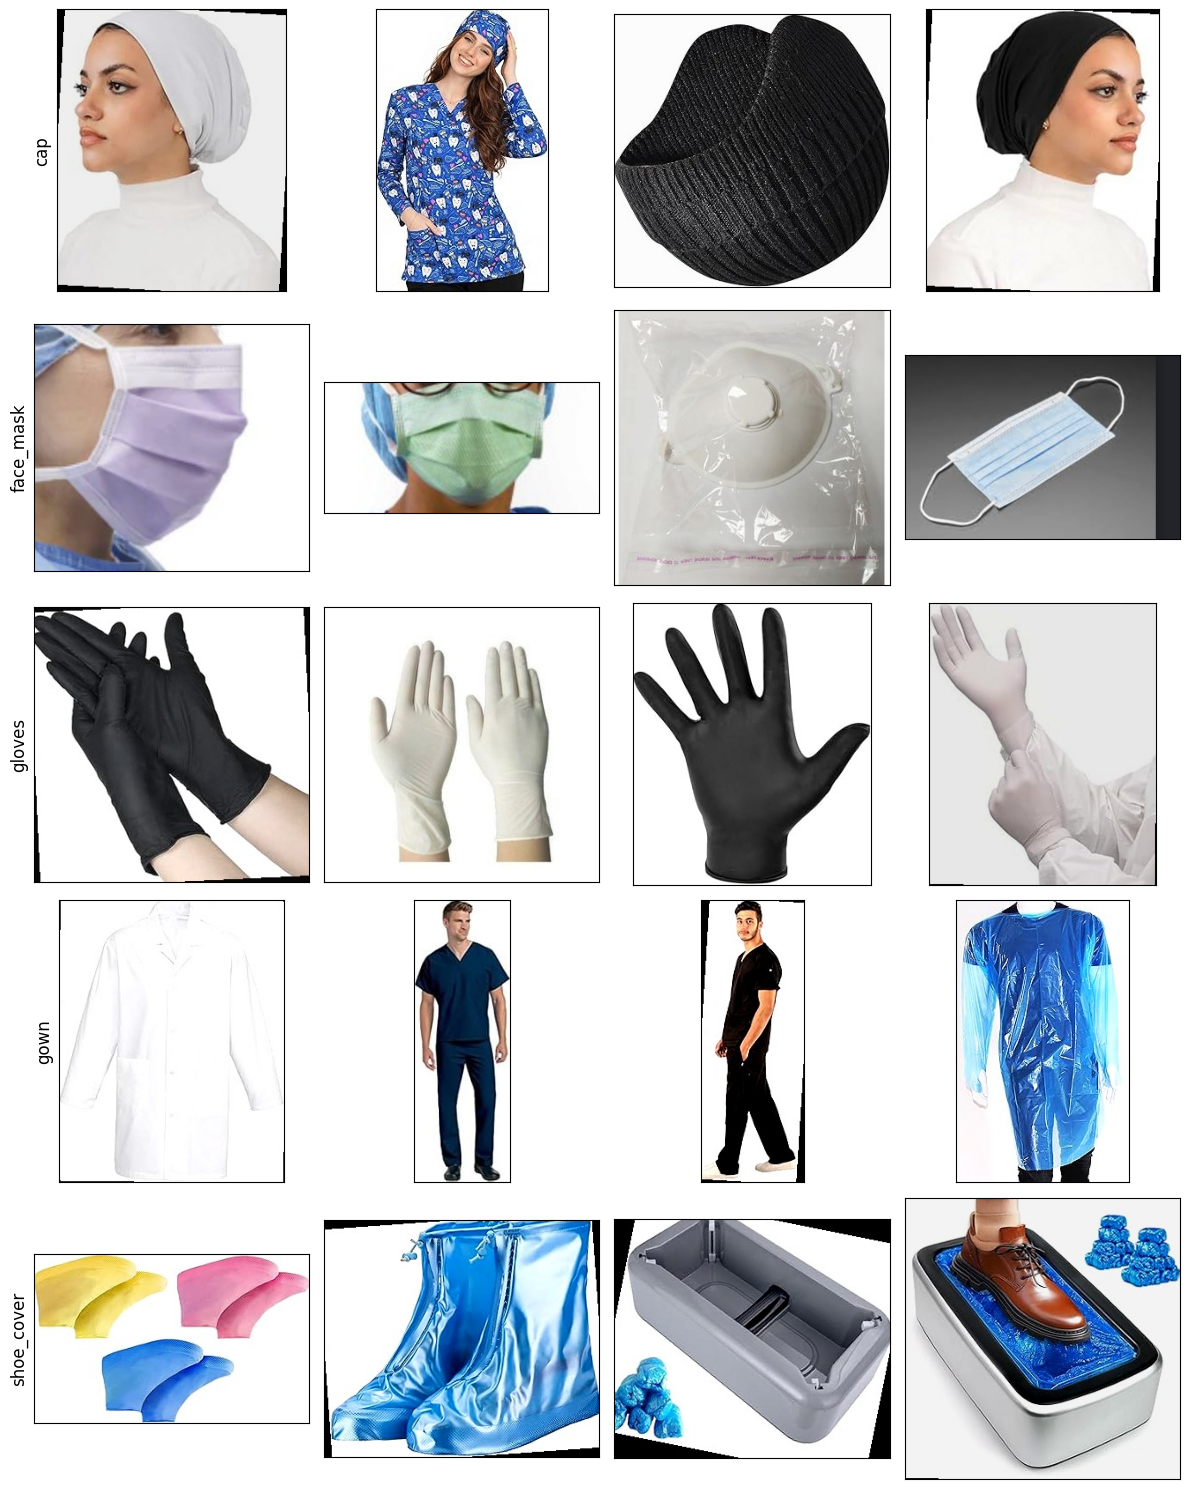

In [ ]:

# Cell 11: Sample Images


print("Sample Images From Each Class")

classes = sorted(df["class"].unique())

# عدد الصور المعروضة لكل كلاس
cols = 4

fig, axes = plt.subplots(
    len(classes),
    cols,
    figsize=(3 * cols, 3 * len(classes))
)

# لو عندك كلاس واحد فقط
if len(classes) == 1:
    axes = np.array([axes])

for row, cls in enumerate(classes):

    subset = df[df["class"] == cls]

    # اختيار صور عشوائية
    samples = subset.sample(
        min(cols, len(subset)),
        random_state=42
    )

    for col in range(cols):

        ax = axes[row, col]

        if col < len(samples):

            img = Image.open(samples.iloc[col]["path"])

            ax.imshow(img)

            if col == 0:
                ax.set_ylabel(cls, fontsize=12)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

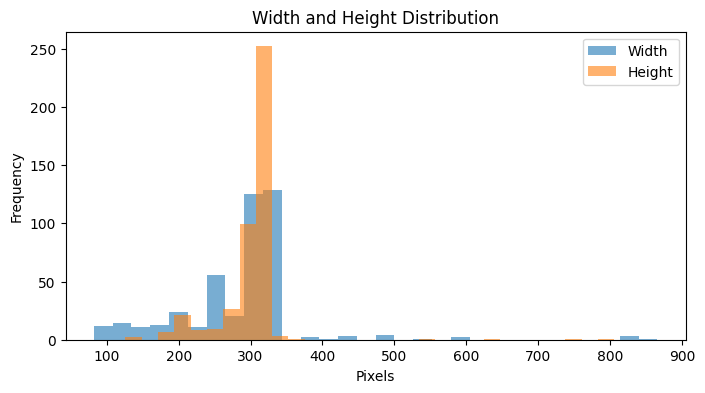

In [ ]:

# Cell 12: Width & Height Distribution


valid_df = df.dropna(subset=["width", "height"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(valid_df["width"], bins=30, alpha=0.6, label="Width")
ax.hist(valid_df["height"], bins=30, alpha=0.6, label="Height")

ax.set_title("Width and Height Distribution")
ax.set_xlabel("Pixels")
ax.set_ylabel("Frequency")

ax.legend()

plt.show()

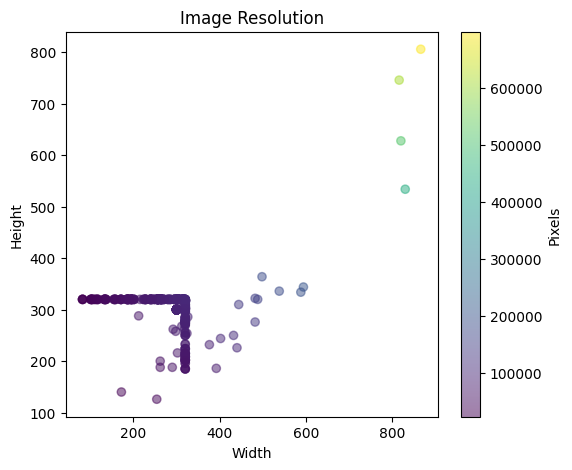

In [ ]:

# Cell 13: Resolution Scatter Plot


fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(
    valid_df["width"],
    valid_df["height"],
    c=valid_df["pixels"],
    alpha=0.5
)

plt.colorbar(scatter, label="Pixels")

ax.set_title("Image Resolution")
ax.set_xlabel("Width")
ax.set_ylabel("Height")

plt.show()

In [ ]:

# Cell 16: Augmentation Notes  lekom ela rawan


print("""
=== Data Augmentation ===

1. Horizontal Flip
   - Helps with left/right camera angles

2. Rotation
   - Simulates tilted camera positions

3. Shear
   - Simulates perspective distortion

4. Grayscale
   - Helps with low-light or monochrome cameras

5. CLAHE
   - Improves contrast in difficult lighting

""")


=== Data Augmentation ===

1. Horizontal Flip
   - Helps with left/right camera angles

2. Rotation
   - Simulates tilted camera positions

3. Shear
   - Simulates perspective distortion

4. Grayscale
   - Helps with low-light or monochrome cameras

5. CLAHE
   - Improves contrast in difficult lighting




Selected Image:
C:\Users\Khale\OneDrive\Desktop\va\balanced_100\face_mask\face_mask_0080.jpg


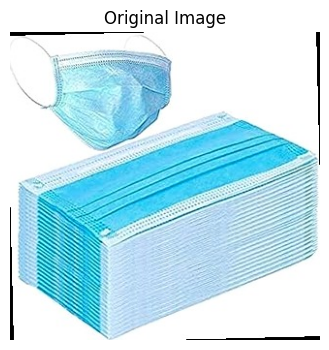

In [ ]:

# Cell 17: Select Random Image


sample = df.sample(1, random_state=7).iloc[0]

image_path = sample["path"]

print("Selected Image:")
print(image_path)

# قراءة الصورة
base = np.array(
    Image.open(image_path).convert("RGB")
)

plt.figure(figsize=(4,4))
plt.imshow(base)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:

# Cell 18: Helper Function


def show_before_after(before, after, title):

    fig, ax = plt.subplots(1, 2, figsize=(8,4))

    ax[0].imshow(before)
    ax[0].set_title("Before")

    # لو الصورة Gray
    if after.ndim == 2:
        ax[1].imshow(after, cmap="gray")
    else:
        ax[1].imshow(after)

    ax[1].set_title("After")

    ax[0].axis("off")
    ax[1].axis("off")

    plt.suptitle(title)

    plt.show()

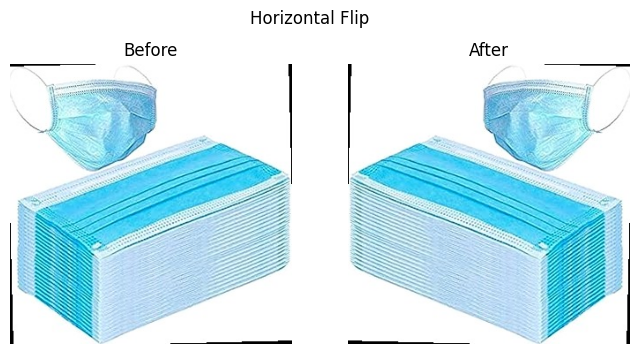

In [ ]:

# Cell 19: Horizontal Flip


flip = A.HorizontalFlip(p=1.0)

after = flip(image=base)["image"]

show_before_after(
    base,
    after,
    "Horizontal Flip"
)

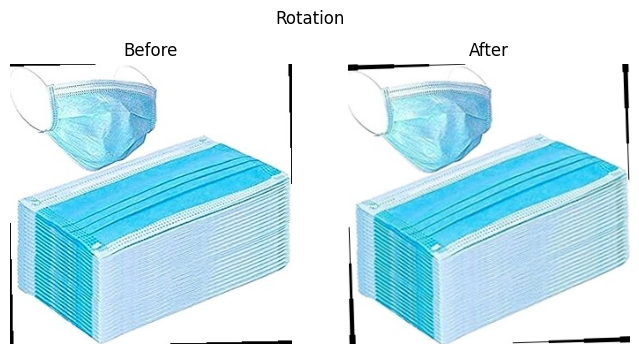

In [ ]:

# Cell 20: Rotation


rotate = A.Rotate(
    limit=20,
    border_mode=cv2.BORDER_REFLECT101,
    p=1.0
)

after = rotate(image=base)["image"]

show_before_after(
    base,
    after,
    "Rotation"
)

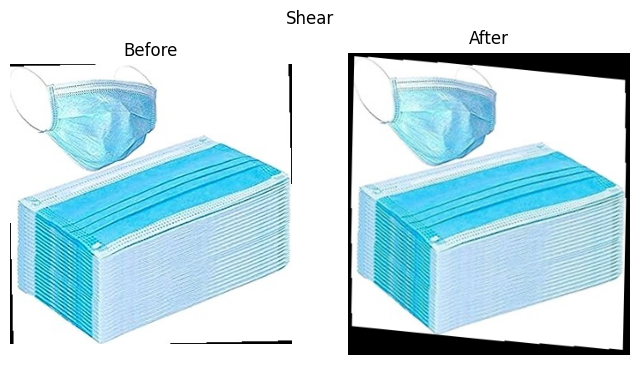

In [ ]:

# Cell 21: Shear


shear = A.Affine(
    shear=(-12, 12),
    fit_output=True,
    p=1.0
)

after = shear(image=base)["image"]

show_before_after(
    base,
    after,
    "Shear"
)

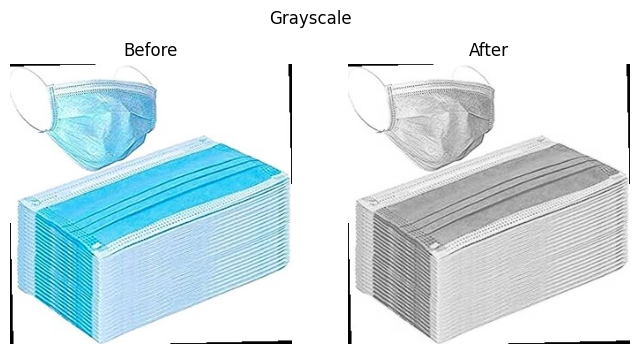

In [ ]:

# Cell 22: Grayscale


gray = A.ToGray(p=1.0)

after = gray(image=base)["image"]

# إزالة البعد لو موجود
if after.ndim == 3 and after.shape[2] == 1:
    after = after.squeeze(-1)

show_before_after(
    base,
    after,
    "Grayscale"
)

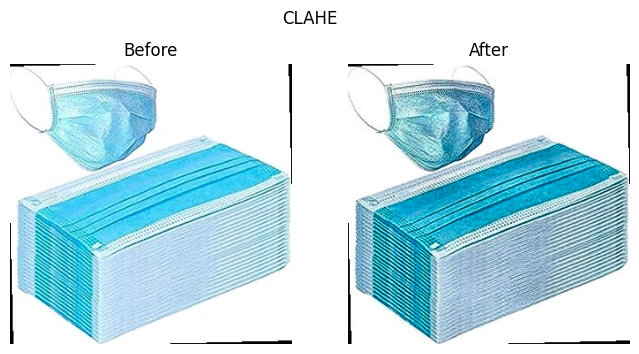

In [ ]:

# Cell 23: CLAHE


clahe = A.CLAHE(
    clip_limit=2.5,
    tile_grid_size=(8,8),
    p=1.0
)

after = clahe(image=base)["image"]

show_before_after(
    base,
    after,
    "CLAHE"
)

In [ ]:

# Cell 24: Optional Perspective


INCLUDE_PERSPECTIVE = False

if INCLUDE_PERSPECTIVE:

    perspective = A.Perspective(
        scale=(0.02, 0.06),
        p=1.0
    )

    after = perspective(image=base)["image"]

    show_before_after(
        base,
        after,
        "Perspective"
    )

In [ ]:

# Cell 25: Training Pipeline


train_aug_stochastic = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=20,
        border_mode=cv2.BORDER_REFLECT101,
        p=0.7
    ),

    A.Affine(
        shear=(-10, 10),
        fit_output=True,
        p=0.3
    ),

    A.OneOf([

        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8,8)
        ),

        A.ToGray(p=1.0)

    ], p=0.15)

])

print("Training augmentation pipeline created")

Training augmentation pipeline created


In [30]:
print("""
عدد الصور الأصلي في الداتا كان 432 صورة، ولو عملنا Data Augmentation وحفظنا 5 نسخ جديدة لكل صورة فعدد الصور هيبقى تقريبًا 2160 صورة بدل 432، وده بيساعد الموديل يشوف أشكال مختلفة من نفس البيانات زي الـ flip والـ rotation والـ CLAHE وبالتالي يتعلم بشكل أحسن ويعمل generalization أقوى، لكن لازم ناخد بالنا إن الصور دي متولدة من نفس الصور الأصلية ومش بديل عن جمع بيانات حقيقية جديدة خصوصًا للكلاسات النادرة.
""")


عدد الصور الأصلي في الداتا كان 432 صورة، ولو عملنا Data Augmentation وحفظنا 5 نسخ جديدة لكل صورة فعدد الصور هيبقى تقريبًا 2160 صورة بدل 432، وده بيساعد الموديل يشوف أشكال مختلفة من نفس البيانات زي الـ flip والـ rotation والـ CLAHE وبالتالي يتعلم بشكل أحسن ويعمل generalization أقوى، لكن لازم ناخد بالنا إن الصور دي متولدة من نفس الصور الأصلية ومش بديل عن جمع بيانات حقيقية جديدة خصوصًا للكلاسات النادرة.



In [ ]:

# Save Augmented Images


from pathlib import Path
from PIL import Image
import numpy as np
import albumentations as A
import cv2

# فولدر الداتا الأصلية
INPUT_DIR = Path(r"C:\Users\Khale\OneDrive\Desktop\va\balanced_100")

# فولدر الداتا الجديدة
OUTPUT_DIR = Path(r"C:\Users\Khale\OneDrive\Desktop\va\augmented_dataset")

OUTPUT_DIR.mkdir(exist_ok=True)

# عدد النسخ الجديدة لكل صورة
NUM_AUGS = 5

# Augmentation Pipeline
transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=20,
        border_mode=cv2.BORDER_REFLECT101,
        p=0.7
    ),

    A.Affine(
        shear=(-10, 10),
        fit_output=False,
        p=0.5
    ),

    A.OneOf([

        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8,8)
        ),

        A.ToGray(p=1.0)

    ], p=0.3)

])

# قراءة الكلاسات
for class_dir in INPUT_DIR.iterdir():

    if class_dir.is_dir():

        # إنشاء فولدر للكلاس
        out_class = OUTPUT_DIR / class_dir.name
        out_class.mkdir(exist_ok=True)

        for img_path in class_dir.iterdir():

            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:

                try:

                    # قراءة الصورة
                    image = np.array(
                        Image.open(img_path).convert("RGB")
                    )

                    # حفظ الصورة الأصلية
                    original_save = out_class / img_path.name

                    Image.fromarray(image).save(original_save)

                    # إنشاء نسخ جديدة
                    for i in range(NUM_AUGS):

                        augmented = transform(image=image)["image"]

                        save_path = out_class / f"{img_path.stem}_aug_{i}.jpg"

                        Image.fromarray(augmented).save(save_path)

                except Exception as e:
                    print("Error:", img_path)
                    print(e)

print("Finished Saving Augmented Dataset")
print("Saved To:")
print(OUTPUT_DIR)

Finished Saving Augmented Dataset
Saved To:
C:\Users\Khale\OneDrive\Desktop\va\augmented_dataset
